# Test Perceptron on a basic dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
cwd = os.getcwd()
root_dir = os.path.dirname(os.path.dirname(cwd))
dataset_dir = os.path.join(root_dir, "datasets")
dataset_file_path = os.path.join(dataset_dir, "placement.csv")
dataset_file_path

'/home/abrar/Programming/ML/datasets/placement.csv'

In [3]:
df = pd.read_csv(dataset_file_path)
df

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


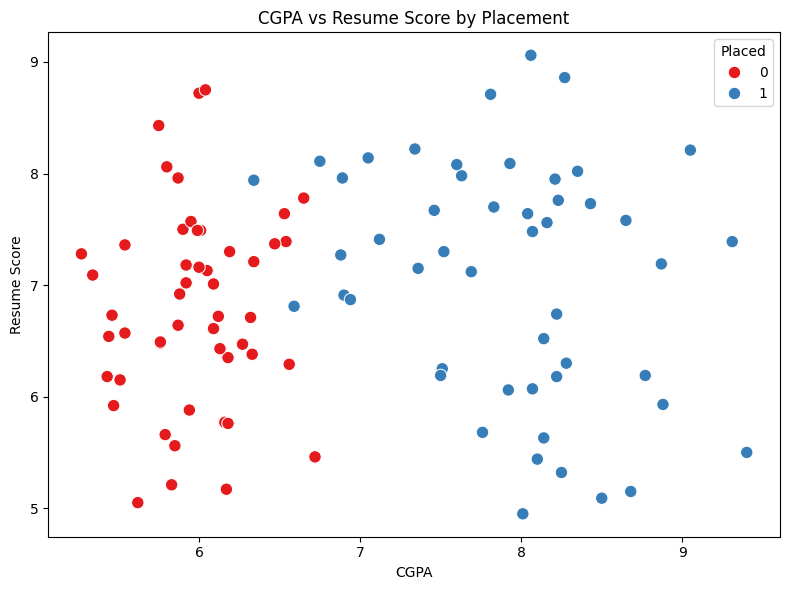

In [4]:
# Create a plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='cgpa', y='resume_score', hue='placed', palette='Set1', s=80)
plt.title('CGPA vs Resume Score by Placement')
plt.xlabel('CGPA')
plt.ylabel('Resume Score')
plt.legend(title='Placed')
plt.tight_layout()
plt.show()

In [ ]:


class PlacementDataset(Dataset):
    def __init__(self, features, labels):
        # Normalization could be done. But unnecessaary for this demonstration.
        self.features = torch.tensor(features.values, dtype=torch.float32)        
        self.labels = torch.tensor(labels.values, dtype=torch.float32)
    
    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [6]:
placement_dataset = PlacementDataset(df[['cgpa', 'resume_score']], df[['placed']])

In [7]:
placement_dataset.features[0], placement_dataset.labels[0], len(placement_dataset)

(tensor([8.1400, 6.5200]), tensor([1.]), 100)

In [8]:
placement_dataloader = DataLoader(placement_dataset, batch_size=20, shuffle=True)

In [9]:
# Model Definition
class Perceptron(nn.Module):
    
    def __init__(self, num_inputs):
        super().__init__()
        self.linear = nn.Linear(num_inputs, 1)
        
    def forward(self, x):
        return self.linear(x)
        

In [10]:
model = Perceptron(placement_dataset.features.shape[1])

In [11]:
# Learning Rate epoch count
lr = 0.01
num_epochs = 50

# Loss function and optimizer
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [12]:
model.linear.weight, model.linear.bias

(Parameter containing:
 tensor([[0.0220, 0.1449]], requires_grad=True),
 Parameter containing:
 tensor([0.3384], requires_grad=True))

In [13]:
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_features, batch_labels in placement_dataloader:
        outputs = model(batch_features) # Pytorch builds a computation graph        
        # Calculate loss
        loss = loss_function(outputs, batch_labels)
        epoch_loss += loss.item()
        
        # Clear gradients
        optimizer.zero_grad()
        
        # Backward pass
        loss.backward() # Calculates params.grad
        
        # Update Gradients
        optimizer.step() # Looks at param.grad and updates them
        
    print(f"Epoch :{epoch + 1}, Loss: {epoch_loss/len(placement_dataloader)}")

Epoch :1, Loss: 0.8451771974563599
Epoch :2, Loss: 0.7393569827079773
Epoch :3, Loss: 0.7250628352165223
Epoch :4, Loss: 0.7213045358657837
Epoch :5, Loss: 0.7100680470466614
Epoch :6, Loss: 0.7128332376480102
Epoch :7, Loss: 0.6996774077415466
Epoch :8, Loss: 0.6960240483283997
Epoch :9, Loss: 0.692425012588501
Epoch :10, Loss: 0.6873333930969239
Epoch :11, Loss: 0.6857980370521546
Epoch :12, Loss: 0.6798089504241943
Epoch :13, Loss: 0.6783732533454895
Epoch :14, Loss: 0.6736695766448975
Epoch :15, Loss: 0.6710618376731873
Epoch :16, Loss: 0.665262770652771
Epoch :17, Loss: 0.6614484190940857
Epoch :18, Loss: 0.6594385862350464
Epoch :19, Loss: 0.6591680765151977
Epoch :20, Loss: 0.651905643939972
Epoch :21, Loss: 0.6543723344802856
Epoch :22, Loss: 0.6468194961547852
Epoch :23, Loss: 0.6467726588249206
Epoch :24, Loss: 0.6411779642105102
Epoch :25, Loss: 0.6375467777252197
Epoch :26, Loss: 0.6379190683364868
Epoch :27, Loss: 0.6339191555976867
Epoch :28, Loss: 0.6327807307243347
Epoc

In [14]:
model.eval()
tp = tn = fp = fn = 0
with torch.no_grad():
    for batch_features, batch_labels in placement_dataloader:
        logits = model(batch_features)
        probs = torch.sigmoid(logits)
        preds = (probs>=0.5).long().reshape(-1)
        labels = batch_labels.long().reshape(-1)
        
        tp += ((preds == 1) & (labels == 1)).sum().item()
        tn += ((preds == 0) & (labels == 0)).sum().item()
        fp += ((preds == 1) & (labels == 0)).sum().item()
        fn += ((preds == 0) & (labels == 1)).sum().item()
        
    accuracy = (tp + tn)/(tp + tn + fp + fn)
    precision = (tp)/(tp + fp) 
    recall = (tp)/(tp+fn)
    f1_score = 2 * ((precision * recall)/(precision + recall)) 
    print(accuracy, precision, recall,f1_score)

0.75 0.711864406779661 0.84 0.7706422018348624


In [15]:
arr = torch.tensor([1, 2, 3])
arr.sum().item()

6